### Project Title

#### AI-Powered Loan Default Predictor

### Objective


To build an AI-driven system that predicts the likelihood of loan default using borrower profiles and financial behavior data. This will enable fintechs and microfinance institutions to make data-informed lending decisions.

### Problem Statement

Loan default is a major risk in digital lending, especially in emerging markets like Nigeria where credit history may be sparse. A predictive system using behavioral and transactional data can improve risk assessment beyond traditional credit scoring methods.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler, OneHotEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, average_precision_score

from scipy import stats

import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Show all columns in outputs
pd.set_option('display.max_columns', None)

#  Optional: Show all rows (be careful with huge datasets)
# pd.set_option('display.max_rows', None)

In [3]:
# Reading compressed Lending Club file
# df = pd.read_csv("data/accepted_2007_to_2018Q4.csv.gz", compression='gzip')

# Sampling 100000 rows from the dataset
# df = df.sample(n=100000, random_state=42)

In [6]:
df = pd.read_csv("data/sampled_lending_data.csv")
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,39651438,NaN,32000.0,32000.0,32000.0,60 months,10.49,687.65,B,B3,Public Service,10+ years,MORTGAGE,120000.0,Verified,Feb-2015,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,919xx,CA,24.05,0.0,Oct-1981,735.0,739.0,0.0,NaN,NaN,20.0,0.0,39687.0,57.8,42.0,w,7181.91,7181.91,33676.200000,33676.20,24818.09,8858.11,0.0,0.0,0.0,Mar-2019,687.65,Apr-2019,Mar-2019,794.0,790.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,457317.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,82400.0,NaN,NaN,NaN,6.0,26901.0,31079.0,71.2,0.0,0.0,154.0,165.0,1.0,1.0,2.0,9.0,NaN,7.0,NaN,0.0,6.0,11.0,8.0,20.0,7.0,14.0,31.0,11.0,20.0,0.0,0.0,0.0,4.0,100.0,28.6,0.0,0.0,556496.0,103647.0,64100.0,72197.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,16411620,NaN,9600.0,9600.0,9600.0,36 months,12.99,323.42,C,C1,NaN,NaN,RENT,21900.0,Verified,May-2014,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,331xx,FL,10.03,0.0,Apr-2001,685.0,689.0,1.0,NaN,118.0,13.0,1.0,4509.0,38.9,20.0,w,0.00,0.00,11643.969042,11643.97,9600.00,2043.97,0.0,0.0,0.0,Jun-2017,0.85,NaN,Aug-2017,544.0,540.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,4509.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11600.0,NaN,NaN,NaN,6.0,347.0,871.0,63.7,0.0,0.0,97.0,157.0,1.0,1.0,0.0,26.0,NaN,1.0,NaN,0.0,2.0,5.0,2.0,5.0,2.0,13.0,18.0,5.0,13.0,0.0,0.0,0.0,2.0,100.0,50.0,1.0,0.0,11600.0,4509.0,2400.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [7]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 151 columns):
 #    Column                                      Dtype  
---   ------                                      -----  
 0    id                                          object 
 1    member_id                                   float64
 2    loan_amnt                                   float64
 3    funded_amnt                                 float64
 4    funded_amnt_inv                             float64
 5    term                                        object 
 6    int_rate                                    float64
 7    installment                                 float64
 8    grade                                       object 
 9    sub_grade                                   object 
 10   emp_title                                   object 
 11   emp_length                                  object 
 12   home_ownership                              object 
 13   annual_inc   

In [8]:
df.loan_status.unique()

array(['Current', 'Fully Paid', 'Charged Off', 'Late (31-120 days)',
       'Late (16-30 days)', 'In Grace Period',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off', nan],
      dtype=object)

In [9]:
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]
df['loan_status'] = df['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})

In [10]:
df.shape

(59494, 151)

In [11]:
# Keep only relevant raw features + target
cols = [
    # Loan
    'loan_amnt', 'term', 'int_rate', 'installment', 'purpose', 'grade',
    # Borrower
    'annual_inc', 'emp_length', 'home_ownership', 'verification_status',
    # Credit
    'dti', 'open_acc', 'total_acc', 'inq_last_6mths',
    'revol_util', 'delinq_2yrs', 'pub_rec', 'revol_bal',
    # Target
    'loan_status'
]

df = df[cols].copy()
print(df.shape)
print(df.isnull().sum())

(59494, 19)
loan_amnt                 0
term                      0
int_rate                  0
installment               0
purpose                   0
grade                     0
annual_inc                0
emp_length             3470
home_ownership            0
verification_status       0
dti                      20
open_acc                  0
total_acc                 0
inq_last_6mths            0
revol_util               32
delinq_2yrs               0
pub_rec                   0
revol_bal                 0
loan_status               0
dtype: int64


In [12]:
# emp_length: 354 nulls — fill with most frequent
df['emp_length'] = df['emp_length'].fillna(df['emp_length'].mode()[0])

# dti: 1 null — fill with median
df['dti'] = df['dti'].fillna(df['dti'].median())

# revol_util: 3 nulls — fill with median
df['revol_util'] = df['revol_util'].fillna(df['revol_util'].median())

print(df.isnull().sum().sum())  # should be 0
print(df.shape)

0
(59494, 19)


In [13]:
# term: remove " months" and convert to int
df['term'] = df['term'].str.strip().str.replace(' months', '').astype(int)

# emp_length: convert to numeric
emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
    '8 years': 8, '9 years': 9, '10+ years': 10
}
df['emp_length'] = df['emp_length'].map(emp_map)

print(df.dtypes)
print(df[['term', 'emp_length']].head())

loan_amnt              float64
term                     int32
int_rate               float64
installment            float64
purpose                 object
grade                   object
annual_inc             float64
emp_length               int64
home_ownership          object
verification_status     object
dti                    float64
open_acc               float64
total_acc              float64
inq_last_6mths         float64
revol_util             float64
delinq_2yrs            float64
pub_rec                float64
revol_bal              float64
loan_status              int64
dtype: object
   term  emp_length
1    36          10
2    36           4
3    36          10
5    36          10
6    36          10


In [14]:
# --- Grade encoding ---
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df['grade_numeric'] = df['grade'].map(grade_map)
df['high_risk_grade'] = (df['grade_numeric'] >= 5).astype(int)

# --- DTI flags ---
df['high_dti_flag'] = (df['dti'] > 30).astype(int)

# --- Income derived ---
df['loan_to_monthly_income'] = df['loan_amnt'] / (df['annual_inc'] / 12)
df['debt_to_income_ratio'] = df['dti'] / 100

# --- Credit inquiry pressure ---
df['inquiry_pressure'] = df['inq_last_6mths'] / (df['open_acc'] + 1)

# --- Employment stability ---
df['stable_employment'] = (df['emp_length'] >= 2).astype(int)
df['very_stable_employment'] = (df['emp_length'] >= 5).astype(int)

# --- Utilization flags ---
df['high_utilization'] = (df['revol_util'] > 75).astype(int)
df['very_high_utilization'] = (df['revol_util'] > 90).astype(int)

# --- Loan flags ---
df['large_loan_flag'] = (df['loan_amnt'] > 20000).astype(int)
df['long_term_loan'] = (df['term'] == 60).astype(int)

# --- Account diversity ---
df['account_diversity'] = df['open_acc'] / (df['total_acc'] + 1)

# --- Verification strength ---
verification_map = {'Not Verified': 0, 'Source Verified': 1, 'Verified': 2}
df['verification_strength'] = df['verification_status'].map(verification_map)
df['strong_verification'] = (df['verification_strength'] == 2).astype(int)

# --- Purpose risk score ---
purpose_risk_map = {
    'credit_card': 0.2, 'car': 0.2, 'home_improvement': 0.2,
    'major_purchase': 0.3, 'medical': 0.3, 'wedding': 0.3,
    'vacation': 0.4, 'moving': 0.4, 'house': 0.4,
    'debt_consolidation': 0.5, 'other': 0.5,
    'small_business': 0.7, 'renewable_energy': 0.5,
    'educational': 0.4
}
df['purpose_risk_score'] = df['purpose'].map(purpose_risk_map).fillna(0.5)
df['high_risk_purpose'] = (df['purpose_risk_score'] >= 0.5).astype(int)

print(df.shape)
print(df.isnull().sum().sum())

(59494, 36)
0


In [15]:
print(df.columns.tolist())
print(df.dtypes)

['loan_amnt', 'term', 'int_rate', 'installment', 'purpose', 'grade', 'annual_inc', 'emp_length', 'home_ownership', 'verification_status', 'dti', 'open_acc', 'total_acc', 'inq_last_6mths', 'revol_util', 'delinq_2yrs', 'pub_rec', 'revol_bal', 'loan_status', 'grade_numeric', 'high_risk_grade', 'high_dti_flag', 'loan_to_monthly_income', 'debt_to_income_ratio', 'inquiry_pressure', 'stable_employment', 'very_stable_employment', 'high_utilization', 'very_high_utilization', 'large_loan_flag', 'long_term_loan', 'account_diversity', 'verification_strength', 'strong_verification', 'purpose_risk_score', 'high_risk_purpose']
loan_amnt                 float64
term                        int32
int_rate                  float64
installment               float64
purpose                    object
grade                      object
annual_inc                float64
emp_length                  int64
home_ownership             object
verification_status        object
dti                       float64
open_a

In [16]:
drop_cols = [
    'verification_status', 'emp_length', 'grade', 'purpose',
    'debt_to_income_ratio', 'high_risk_purpose', 'very_stable_employment',
    'strong_verification', 'high_risk_grade', 'inquiry_pressure', 'high_utilization'
]

df = df.drop(columns=drop_cols)

X = df.drop(columns=['loan_status'])
y = df['loan_status']

print(X.shape)
print(X.columns.tolist())

(59494, 24)
['loan_amnt', 'term', 'int_rate', 'installment', 'annual_inc', 'home_ownership', 'dti', 'open_acc', 'total_acc', 'inq_last_6mths', 'revol_util', 'delinq_2yrs', 'pub_rec', 'revol_bal', 'grade_numeric', 'high_dti_flag', 'loan_to_monthly_income', 'stable_employment', 'very_high_utilization', 'large_loan_flag', 'long_term_loan', 'account_diversity', 'verification_strength', 'purpose_risk_score']


In [17]:
# y_train.shape

In [18]:
# X_train_df = pd.DataFrame(X, columns=feature_names)
# X_train_df.head()

In [19]:
# check which columns have inf
X_mi = X.copy()
print(X_mi.isin([np.inf, -np.inf]).sum())

loan_amnt                  0
term                       0
int_rate                   0
installment                0
annual_inc                 0
home_ownership             0
dti                        0
open_acc                   0
total_acc                  0
inq_last_6mths             0
revol_util                 0
delinq_2yrs                0
pub_rec                    0
revol_bal                  0
grade_numeric              0
high_dti_flag              0
loan_to_monthly_income    20
stable_employment          0
very_high_utilization      0
large_loan_flag            0
long_term_loan             0
account_diversity          0
verification_strength      0
purpose_risk_score         0
dtype: int64


In [20]:

X_mi['home_ownership'] = OrdinalEncoder().fit_transform(X_mi[['home_ownership']])
X_mi = X_mi.replace([np.inf, -np.inf], np.nan)
X_mi = X_mi.fillna(X_mi.median())

mi_scores = mutual_info_classif(X_mi, y, random_state=42)

mi_df = pd.DataFrame({
    'feature': X_mi.columns.tolist(),
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

print(mi_df.to_string(index=False))
print(X.shape)

               feature  mi_score
              int_rate  0.038542
         grade_numeric  0.035683
           installment  0.021457
                  term  0.017903
        long_term_loan  0.016818
loan_to_monthly_income  0.011025
     stable_employment  0.008156
        home_ownership  0.007139
                   dti  0.005896
             loan_amnt  0.005314
    purpose_risk_score  0.005051
        inq_last_6mths  0.004948
 verification_strength  0.004205
            annual_inc  0.003650
       large_loan_flag  0.002570
         high_dti_flag  0.002359
           delinq_2yrs  0.002282
             revol_bal  0.001485
     account_diversity  0.001085
            revol_util  0.000574
               pub_rec  0.000302
              open_acc  0.000022
             total_acc  0.000000
 very_high_utilization  0.000000
(59494, 24)


In [21]:
drop_low_mi = [
    'delinq_2yrs', 'very_high_utilization', 'large_loan_flag',
    'open_acc', 'account_diversity', 'high_dti_flag', 'revol_util'
]

X = X.drop(columns=drop_low_mi)
print(X.shape)
print(X.columns.tolist())

(59494, 17)
['loan_amnt', 'term', 'int_rate', 'installment', 'annual_inc', 'home_ownership', 'dti', 'total_acc', 'inq_last_6mths', 'pub_rec', 'revol_bal', 'grade_numeric', 'loan_to_monthly_income', 'stable_employment', 'long_term_loan', 'verification_strength', 'purpose_risk_score']


In [22]:
final_columns = ['loan_amnt', 'term', 'int_rate', 'installment', 'annual_inc',
 'home_ownership', 'dti', 'total_acc', 'inq_last_6mths', 'pub_rec', 'revol_bal',
 'grade_numeric', 'loan_to_monthly_income',
 'stable_employment', 'long_term_loan',
 'verification_strength', 'purpose_risk_score', 'loan_status']

In [23]:
lending_df = df[final_columns]

In [24]:
lending_df.shape

(59494, 18)

In [25]:
lending_df.head()

,loan_amnt,term,int_rate,installment,annual_inc,home_ownership,dti,total_acc,inq_last_6mths,pub_rec,revol_bal,grade_numeric,loan_to_monthly_income,stable_employment,long_term_loan,verification_strength,purpose_risk_score,loan_status
1,9600.0,36,12.99,323.42,21900.0,RENT,10.03,20.0,1.0,1.0,4509.0,3,5.260274,1,0,2,0.5,0
2,4000.0,36,6.68,122.93,83000.0,MORTGAGE,19.53,25.0,0.0,0.0,1564.0,1,0.578313,1,0,0,0.3,0
3,6025.0,36,10.91,197.00,52000.0,RENT,9.16,25.0,1.0,0.0,2706.0,2,1.390385,1,0,0,0.5,0
5,20000.0,36,9.49,640.57,100000.0,MORTGAGE,16.43,32.0,0.0,0.0,20440.0,2,2.400000,1,0,0,0.5,0
6,1000.0,36,8.18,31.42,23000.0,RENT,16.34,38.0,0.0,0.0,3237.0,2,0.521739,1,0,2,0.5,0


In [19]:
# Final 17 features — all derivable from raw user inputs
numeric_features = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'annual_inc',
    'dti', 'total_acc', 'inq_last_6mths', 'pub_rec', 'revol_bal',
    'grade_numeric', 'loan_to_monthly_income',
    'stable_employment', 'long_term_loan',
    'verification_strength', 'purpose_risk_score'
]

categorical_features = ['home_ownership']

print(X.shape)
print(X.columns.tolist())

(59494, 17)
['loan_amnt', 'term', 'int_rate', 'installment', 'annual_inc', 'home_ownership', 'dti', 'total_acc', 'inq_last_6mths', 'pub_rec', 'revol_bal', 'grade_numeric', 'loan_to_monthly_income', 'stable_employment', 'long_term_loan', 'verification_strength', 'purpose_risk_score']


In [20]:


X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

print(X.isin([np.inf, -np.inf]).sum().sum())  # should be 0
print(X.isnull().sum().sum())                 # should be 0

test_size=0.2
val_size=0.15
random_state=42

# Train/test split
# First split: train + val vs test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # Second split: train vs val
val_ratio = val_size / (1 - test_size)  # Adjust ratio for remaining data
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_ratio, random_state=random_state, stratify=y_temp
    )

# Preprocessor
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Fit preprocessor
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)



# Save
joblib.dump(preprocessor, 'models/preprocessor.pkl')
print("Saved.")

0
0
Saved.


In [21]:
X_train_processed.shape, X_val_processed.shape, X_test_processed.shape

((38670, 17), (8925, 17), (11899, 17))

In [22]:

smote = SMOTE(random_state=42)
X_train, y_train_bal = smote.fit_resample(X_train_processed, y_train)

print("Before SMOTE:", Counter(y_train))
print(f"After SMOTE: ", Counter(y_train_bal))

Before SMOTE: Counter({0: 30848, 1: 7822})
After SMOTE:  Counter({0: 30848, 1: 30848})


In [23]:
feature_names = numeric_features + categorical_features


raw_input_features = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'annual_inc',
    'home_ownership', 'dti', 'total_acc', 'inq_last_6mths',
    'pub_rec', 'revol_bal', 'grade', 'emp_length',
    'verification_status', 'purpose'
]

joblib.dump(feature_names, 'feature_names.pkl')
joblib.dump(raw_input_features, 'raw_input_features.pkl')
print("Saved.")
print(feature_names)
print(raw_input_features)

Saved.
['loan_amnt', 'term', 'int_rate', 'installment', 'annual_inc', 'dti', 'total_acc', 'inq_last_6mths', 'pub_rec', 'revol_bal', 'grade_numeric', 'loan_to_monthly_income', 'stable_employment', 'long_term_loan', 'verification_strength', 'purpose_risk_score', 'home_ownership']
['loan_amnt', 'term', 'int_rate', 'installment', 'annual_inc', 'home_ownership', 'dti', 'total_acc', 'inq_last_6mths', 'pub_rec', 'revol_bal', 'grade', 'emp_length', 'verification_status', 'purpose']


In [24]:
print(preprocessor.feature_names_in_)

['loan_amnt' 'term' 'int_rate' 'installment' 'annual_inc' 'home_ownership'
 'dti' 'total_acc' 'inq_last_6mths' 'pub_rec' 'revol_bal' 'grade_numeric'
 'loan_to_monthly_income' 'stable_employment' 'long_term_loan'
 'verification_strength' 'purpose_risk_score']


In [25]:
X_train.shape, y_train_bal.shape, X_test_processed.shape,  y_test.shape, X_val_processed.shape, y_val.shape

((61696, 17), (61696,), (11899, 17), (11899,), (8925, 17), (8925,))

In [26]:

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Evaluation function
def evaluate_models(models, X_train, y_train, X_val, y_val):
    results = []

    for name, model in models.items():
        model.fit(X_train, y_train)

        y_pred_1 = model.predict(X_val)
        y_proba_1 = model.predict_proba(X_val)[:,1] if hasattr(model, "predict_proba") else None

        acc = accuracy_score(y_val, y_pred_1)
        prec = precision_score(y_val, y_pred_1, zero_division=0)
        rec = recall_score(y_val, y_pred_1, zero_division=0)
        f1 = f1_score(y_val, y_pred_1, zero_division=0)
        roc_auc = roc_auc_score(y_val, y_proba_1) if y_proba_1 is not None else None

        results.append({
            "Model": name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1,
            "ROC_AUC": roc_auc
        })

    return pd.DataFrame(results).sort_values(by="F1", ascending=False)

results_df = evaluate_models(models, X_train, y_train_bal, X_val_processed, y_val)


In [27]:
results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.669916,0.333625,0.633795,0.437142,0.717531
3,Naive Bayes,0.664090,0.327551,0.627701,0.430471,0.700537
4,Gradient Boosting,0.730756,0.370338,0.473130,0.415471,0.704301
1,Random Forest,0.759552,0.377426,0.290859,0.328536,0.688573
2,Decision Tree,0.666218,0.257638,0.345706,0.295245,0.546589
5,XGBoost,0.781064,0.419285,0.214404,0.283724,0.678375


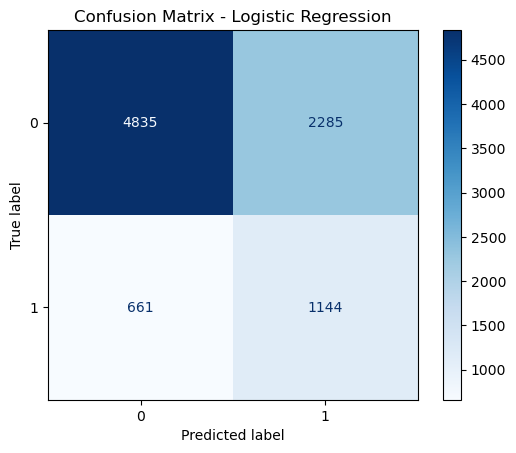

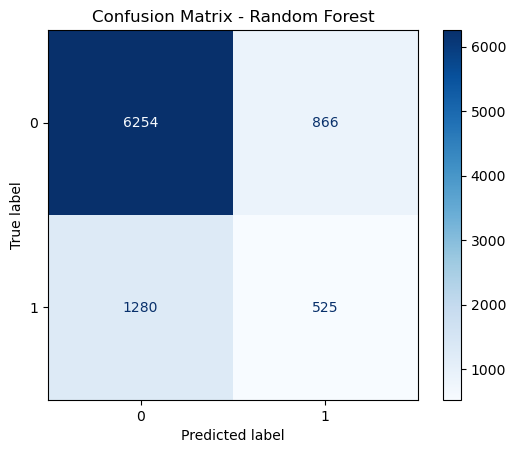

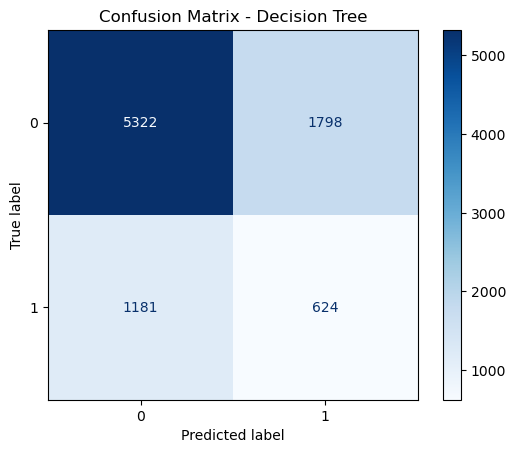

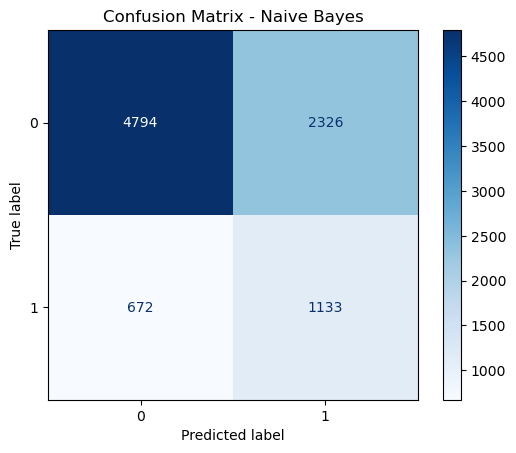

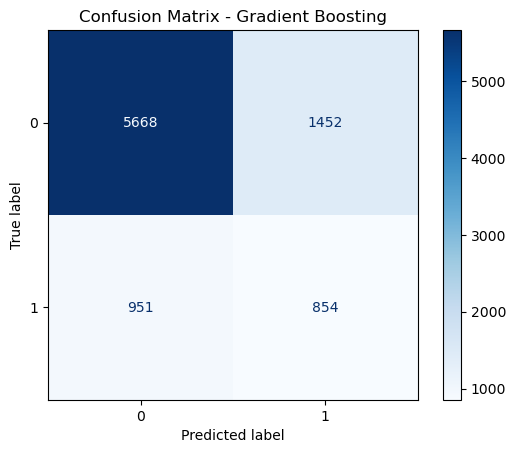

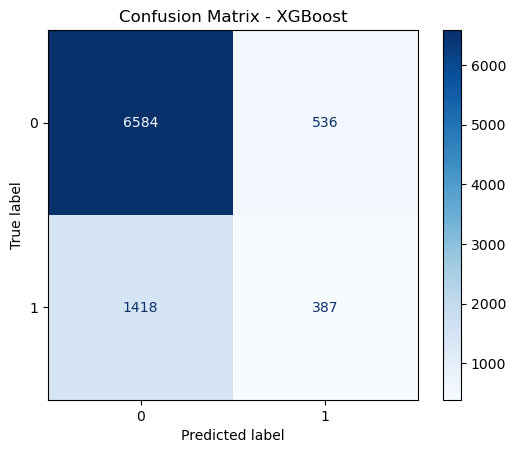

In [28]:
# Function to plot confusion matrices for already trained models
def plot_confusion_matrices(models, X_val, y_val):
    for name, model in models.items():
        y_pred = model.predict(X_val)
        cm = confusion_matrix(y_val, y_pred)

        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap="Blues", values_format="d")
        plt.title(f"Confusion Matrix - {name}")
        plt.show()

plot_confusion_matrices(models, X_val_processed, y_val)

In [29]:
background = X_val_processed
joblib.dump(background, "models/background.pkl")

['models/background.pkl']

In [30]:
# Defining the base model

log_reg = LogisticRegression(max_iter=5000, solver="liblinear")

# hyperparameter grid
param_grid = {
    "penalty": ["l1", "l2", "elasticnet", None],  # different regularization
    "C": [0.1, 1, 10, 100]                 # regularization strength
}

# StratifiedKFold to ensure class balance is preserved in splits
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearch with cross-validation
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train, y_train_bal)

print("Best Hyperparameters:", grid_search.best_params_) # Print best hyperparameters

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Hyperparameters: {'C': 100, 'penalty': 'l2'}


In [31]:
# Evaluate on validation set
y_val_pred = grid_search.predict(X_val_processed)
y_val_prob_1 = grid_search.predict_proba(X_val_processed)[:, 1]

print("\nValidation Results:")
print(classification_report(y_val, y_val_pred))
print("Validation ROC-AUC:", roc_auc_score(y_val, y_val_prob_1))
print(confusion_matrix(y_val, y_val_pred))


Validation Results:
              precision    recall  f1-score   support

           0       0.88      0.68      0.77      7120
           1       0.33      0.63      0.44      1805

    accuracy                           0.67      8925
   macro avg       0.61      0.66      0.60      8925
weighted avg       0.77      0.67      0.70      8925

Validation ROC-AUC: 0.7175301129820413
[[4831 2289]
 [ 661 1144]]


In [32]:
# Final evaluation on test set
y_test_pred = grid_search.predict(X_test_processed)
y_test_prob = grid_search.predict_proba(X_test_processed)[:, 1]

print("\nTest Results:")
print(classification_report(y_test, y_test_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_test_prob))
print(confusion_matrix(y_test, y_test_pred))


Test Results:
              precision    recall  f1-score   support

           0       0.88      0.67      0.76      9492
           1       0.33      0.63      0.43      2407

    accuracy                           0.66     11899
   macro avg       0.60      0.65      0.60     11899
weighted avg       0.77      0.66      0.70     11899

Test ROC-AUC: 0.6999785619657233
[[6396 3096]
 [ 895 1512]]


In [33]:
# Saving the best model
joblib.dump(grid_search, 'models/model.pkl')

['models/model.pkl']

In [34]:
# Loading the best model
model = joblib.load("models/model.pkl")

In [35]:
model

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...r='liblinear')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'penalty': ['l1', 'l2', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the scor

In [36]:
print("Best parameters:", model.best_params_)
print("Best estimator:", model.best_estimator_)

# making predictions with loaded model
y_pred = model.predict(X_test_processed)
y_prob = grid_search.predict_proba(X_test_processed)[:, 1]

Best parameters: {'C': 100, 'penalty': 'l2'}
Best estimator: LogisticRegression(C=100, max_iter=5000, penalty='l2', solver='liblinear')


In [37]:
print(classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.88      0.67      0.76      9492
           1       0.33      0.63      0.43      2407

    accuracy                           0.66     11899
   macro avg       0.60      0.65      0.60     11899
weighted avg       0.77      0.66      0.70     11899



array([[6396, 3096],
       [ 895, 1512]], dtype=int64)

In [38]:
# Getting coefficients
best_model = grid_search.best_estimator_
coefficients = best_model.coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Abs_Coefficient": np.abs(coefficients)
})

# Sort by absolute coefficient
coef_df = coef_df.sort_values(by="Abs_Coefficient", ascending=False)


In [39]:
coef_df

,Feature,Coefficient,Abs_Coefficient
3,installment,0.410718,0.410718
0,loan_amnt,-0.387436,0.387436
10,grade_numeric,0.375741,0.375741
5,dti,0.214564,0.214564
1,term,0.155432,0.155432
13,long_term_loan,0.155432,0.155432
9,revol_bal,-0.094187,0.094187
2,int_rate,0.089097,0.089097
11,loan_to_monthly_income,0.078179,0.078179
16,home_ownership,0.077698,0.077698


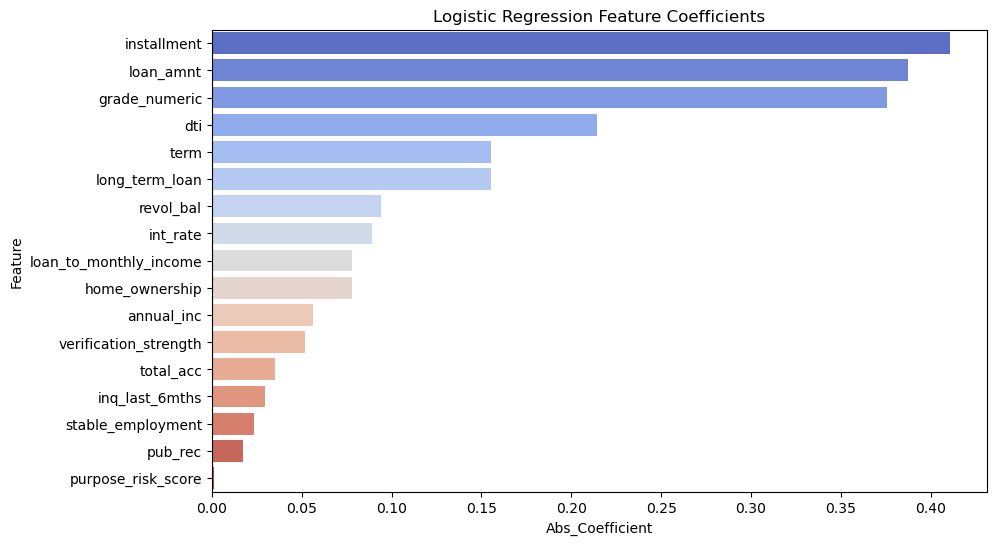

In [42]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_df,
    x="Abs_Coefficient",
    y="Feature",
    palette="coolwarm"
)

plt.axvline(0, color="black", linestyle="--")
plt.title("Logistic Regression Feature Coefficients")
plt.show()

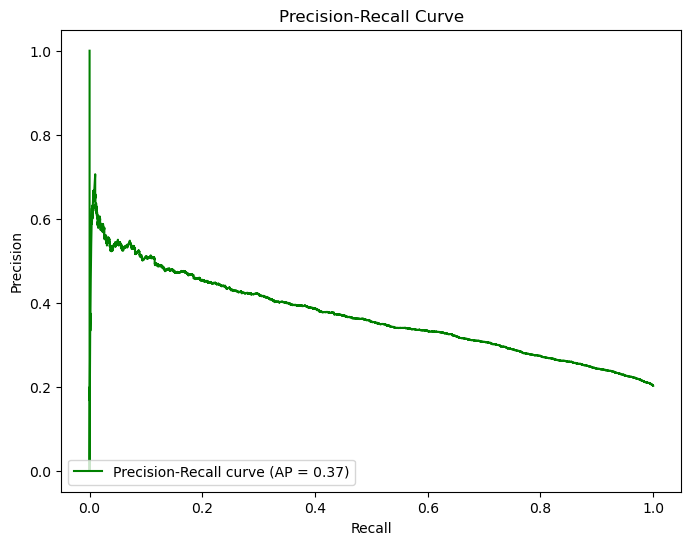

In [41]:
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_prob)
average_precision = average_precision_score(y_test, y_prob)
plt.figure(figsize=(8,6))
plt.plot(recall, precision, color='green', label=f"Precision-Recall curve (AP = {average_precision:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.show()


In [47]:
feature_names

['loan_amnt',
 'term',
 'int_rate',
 'installment',
 'annual_inc',
 'dti',
 'total_acc',
 'inq_last_6mths',
 'pub_rec',
 'revol_bal',
 'grade_numeric',
 'loan_to_monthly_income',
 'stable_employment',
 'long_term_loan',
 'verification_strength',
 'purpose_risk_score',
 'home_ownership']